# Analysis of American Parlimentary Debate Association Rounds Fall 2019 - Spring 2026

## Exploratory Data Analysis

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [150]:
df_rounds = pd.read_csv("Rounds.csv")
df_rounds_with_judge_id = pd.read_csv("All_Rounds_With_Judge.csv")
debate_roster = pd.read_csv("All_Debaters.csv")
df_dropped = pd.read_csv("Lost_Rounds.csv")

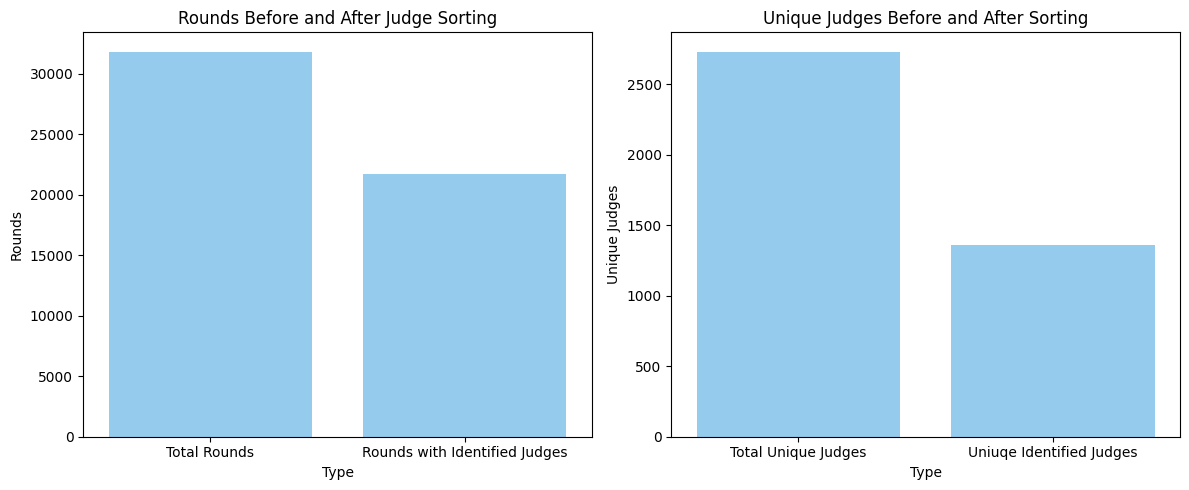

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_rounds_data = pd.DataFrame([[df_rounds.shape[0], "Total Rounds"], [df_rounds_with_judge_id.shape[0], "Rounds with Identified Judges"]], columns=["Rounds","Type"])
sns.barplot(df_rounds_data, x="Type", y="Rounds", orient='v', color="lightskyblue", ax=axes[0])
axes[0].set_title("Rounds Before and After Dropping")

df_debaters_data = pd.DataFrame([[len(df_rounds["Judge"].unique()), "Total Unique Judges"], [len(df_rounds_with_judge_id["Judge"].unique()), "Uniuqe Identified Judges"]], columns=["Unique Judges", "Type"])
sns.barplot(df_debaters_data, x="Type", y="Unique Judges", orient='v', color="lightskyblue", ax=axes[1])
axes[1].set_title("Unique Judges Before and After Sorting")
axes[0].set_title("Rounds Before and After Judge Sorting")

plt.tight_layout()
plt.show()

From this, we can see that the data spans 31,837 rounds and that APDA has 6,155 registered debaters. Finally, the rounds with identified judges are only 21,732. This means that there were 10,105 rounds that were dropped when the dataset of rounds and the valid, registered judges were merged. In these rounds, there were 1,336 unique judges. It can be assumed that the majority of these judges are individuals who have judged but have never competed in an APDA round themselves nor did they go on to compete. This is an important observation since 31.7% of all rounds fall into this group. This also means 47.9% of all unique judges appearing in APDA rounds are never registered with a school.

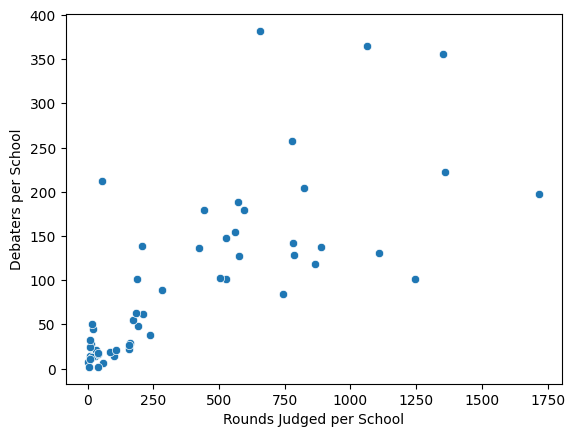

In [182]:
df_rounds_with_judge_id_data = df_rounds_with_judge_id.groupby("Judge School")["Judge"].count().to_frame("Rounds Judged per School")
df_rounds_with_judge_id_data.index.name = "School"


df_debate_roster_data = debate_roster.groupby("School")["Debater"].nunique().to_frame("Debaters per School")

df_debater_count_data = pd.merge(df_rounds_with_judge_id_data, df_debate_roster_data, on='School', how='inner')

sns.scatterplot(data=df_debater_count_data, x="Rounds Judged per School", y="Debaters per School")
plt.show()

In [200]:
df_debater_count_data["Ratio"] = df_debater_count_data["Rounds Judged per School"] / df_debater_count_data["Debaters per School"]
df_debater_count_data = df_debater_count_data.sort_values(by="Ratio", ascending=False)
print(df_debater_count_data.head())
print("\nSeparation\n")
print(df_debater_count_data.tail())
df_debater_count_data.to_csv("test.csv")

                   Rounds Judged per School  Debaters per School      Ratio
School                                                                     
Villanova                                39                    2  19.500000
Northeastern                           1246                  101  12.336634
Drexel                                   58                    6   9.666667
Wellesley                               742                   85   8.729412
George Washington                      1718                  198   8.676768

Separation

                                    Rounds Judged per School  \
School                                                         
University of North Carolina                               8   
MIT                                                       16   
Washington University in St. Louis                        10   
Stanford                                                  56   
Stony Brook University                                     2   

      

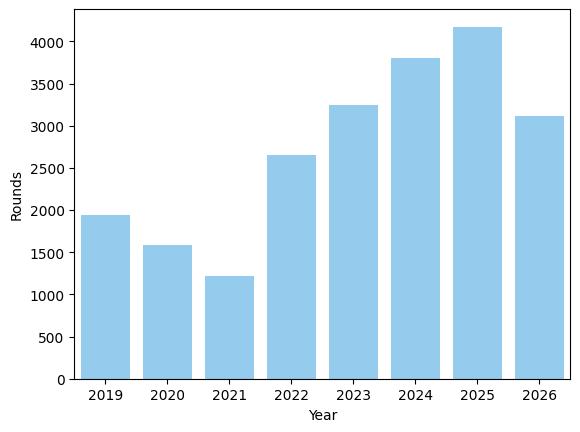

In [192]:
df_rounds_per_year = df_rounds_with_judge_id.groupby("Year")["Season"].count().to_frame("Rounds")
df_rounds_per_year.to_csv("test.csv")
sns.barplot(data=df_rounds_per_year, x=df_rounds_per_year.index, y="Rounds", color="lightskyblue")
plt.show()

Keep in mind 2019 and 2026 are represented by half years